# **Flujo óptico**

## **Flujo óptico: Lucas-Kanade vs. Farnebäck**

### **Lucas–Kanade: implementación manual**

En esta sección, implementamos el método de Lucas-Kanade. Dado que este método es costoso computacionalmente, solamente lo implementaremos para un punto en la imagen. Para ello, preprocesamos la primera imagen para encontrar un punto siguiendo los siguientes pasos:
1. Pasar la imagen a escala de grises.
2. Aplicar filtro gaussiano (visto en la práctica 3 de la asignatura).
3. Detectar bordes con Canny (https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html).
4. Buscar los contornos y escoger un punto del contorno (en este caso, escogemos el punto que menor valor de Y tenga) (https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/).


In [1]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/contours"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

Dimensiones imagen original: (720, 1280, 3)


True

Imagen original:

![original.jpg](output/contours/original.jpg)

In [2]:
# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5, 5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

True

Imagen con suavizado Gaussiano:

![suavizado.jpg](output/contours/suavizado.jpg)

In [3]:
# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)

True

Bordes detectados con Canny:

![canny.jpg](output/contours/canny.jpg)

In [4]:
# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos, _) = cv2.findContours(
    canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
contornos_img = old_gray.copy()
contornos_col = cv2.cvtColor(contornos_img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(contornos_col, contornos, -1, (255, 0, 0), 1)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_col)

cnt = contornos[0]

# punto más arriba
top = cnt[cnt[:, :, 1].argmin()][0]
print(top)

[822 698]


Los contornos encontrados son los siguientes
![Contornos obtenidos en la imagen](output/contours/contornos.jpg)

A continuación, definimos una función aplicar una máscara de tamaño 11x11. Esta máscara definirá la ventana donde calcularemos los cambios de intensidad de la imagen, para que el costo computacional no sea elevado. Esta función se la pedimos a ChatGPT.

In [5]:
def get_mask_11x11(img, point):
    x = int(point[0])
    y = int(point[1])

    x1 = max(0, x - 5)
    x2 = min(img.shape[1], x + 6)

    y1 = max(0, y - 5)
    y2 = min(img.shape[0], y + 6)

    mask = img[y1:y2, x1:x2]
    return mask

Ahora, comenzamos con el flujo principal del método. Analizaremos 2 frames. Para ello, realizamos los siguientes pasos:
1. Obtener las intensidades de la máscara de 11x11 de la imagen 1.
2. Calcular las derivadas de intensidad con Sobel usando los métodos indicados en la página de [OpenCV](https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html).
3. Construir la matriz de las derivadas:

$$S =
\begin{bmatrix}
dx_1 & dy_1 \\
dx_2 & dy_2 \\
\vdots & \vdots \\
dx_9 & dy_9
\end{bmatrix}$$

4. Mostrar el punto en la imagen 1.
5. Obtener las intensidades de la máscara de 11x11 de la imagen 2.
6. Obtener la matriz T:

$$T =
\begin{bmatrix}
I_t(x_1,y_1) - I_{t+\Delta t}(x_1,y_1) \\
I_t(x_2,y_2) - I_{t+\Delta t}(x_2,y_2) \\
\vdots \\
I_t(x_9,y_9) - I_{t+\Delta t}(x_9,y_9)
\end{bmatrix}$$

7. Calcular $\Delta p$ mediante el mínimo error cuadrático medio (explicado en la ecuación 9 del [artículo original](https://www.researchgate.net/publication/215458777_An_Iterative_Image_Registration_Technique_with_an_Application_to_Stereo_Vision_IJCAI), siguiendo la formulación de los apuntes):


$$\Delta p =
\begin{bmatrix}
u \\
v
\end{bmatrix}$$

$$S \, \Delta p = T$$

$$\Delta p = (S^TS)^{-1}S^TT$$

8. Calcular la posición del punto en el siguiente frame.

*(Las fórmulas en .md con matrices se las pedimos a ChatGPT)*


In [ ]:
frame_idx = 0
punto_inicial = top
old_frame_copy = old_frame.copy()

while status:
    if frame_idx == 2:
        break

    # 1. Obtener las intensidades de la máscara de 11x11 de la imagen 1.
    intensidad_1 = get_mask_11x11(old_gray, punto_inicial)
    cv2.imwrite(
        f"{out_dir}/mascara1_frame{frame_idx}.jpg",
        cv2.resize(intensidad_1, (100, 100), interpolation=cv2.INTER_NEAREST),
    )  # cambiamos el tamaño para poder visualizarlo

    # 2. Calcular las derivadas de intensidad con Sobel.
    sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)

    # 3. Construir la matriz de las derivadas
    matrix = np.column_stack((sobelx.ravel(), sobely.ravel()))

    # 4. Mostrar el punto en la imagen 1.
    punto_inicial_int = (int(punto_inicial[0]), int(punto_inicial[1]))
    cv2.circle(old_frame_copy, punto_inicial_int, 2, (0, 0, 255), -1)
    cv2.imshow(f"punto inicial frame {frame_idx}", old_frame_copy)
    cv2.imwrite(f"{out_dir}/punto_inicial_frame{frame_idx}.jpg", old_frame_copy)

    # captura la imagen 2
    ret, img = frame.read()
    if not ret:
        print("No hay más frames o el frame no se pudo leer.")
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 5. Obtener las intensidades de la máscara de 11x11 de la imagen 2.
    intensidad_2 = get_mask_11x11(gray, punto_inicial)
    cv2.imwrite(
        f"{out_dir}/mascara2_frame{frame_idx}.jpg",
        cv2.resize(intensidad_2, (100, 100), interpolation=cv2.INTER_NEAREST),
    )  # cambiamos el tamaño para poder visualizarlo

    # 6. Obtener la matriz T
    # Muy importante convertir a float32 para realizar cálculos (reciclado de prácticas anteriores)
    T = intensidad_1.ravel().astype(np.float32) - intensidad_2.ravel().astype(np.float32)

    # 7. Calcular  diferencial de p
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T 
    print(f"diff_p:\n{diff_p}")

    # 8. Calcular la posición del punto en el siguiente frame.
    top_arr = np.array(punto_inicial, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")

    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))

    # Código pedido a ChatGPT para dibujar una flecha visible
    p0 = top_arr
    vec = new_point - p0
    norm = np.linalg.norm(vec)

    if norm > 1e-6:
        vec_dir = vec / norm       # dirección unitaria
    else:
        vec_dir = np.zeros_like(vec)

    L = 20  # longitud fija de la flecha en píxeles
    end = p0 + L * vec_dir

    p0_int = (int(p0[0]), int(p0[1]))
    end_int = (int(end[0]), int(end[1]))

    cv2.arrowedLine(new, p0_int, end_int, (0, 0, 255), 2, tipLength=0.3)
    # ---

    cv2.circle(new, new_point_int, 2, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)

    cv2.waitKey(0)

    # Actualización de variables
    punto_inicial = new_point
    old_gray = gray
    old_frame_copy = img
    frame_idx += 1

frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

diff_p:
[-0.05835519 -0.00701619]
old point: [822. 698.]
new_point: [821.94164481 697.99298381]
diff_p:
[-0.03208656 -0.12877617]
old point: [821.94165 697.993  ]
new_point: [821.90956383 697.86420479]


Máscara 1 en el frame 0:

![mascara1_frame0.jpg](output/contours/mascara1_frame0.jpg)

Máscara 2 en el frame 0:

![mascara2_frame0.jpg](output/contours/mascara2_frame0.jpg)

Punto inicial en el frame 0:

![punto_inicial_frame0.jpg](output/contours/punto_inicial_frame0.jpg)

Punto final en el frame 0:

![punto_final_frame0.jpg](output/contours/punto_final_frame0.jpg)

Máscara 1 en el frame 1:

![mascara1_frame1.jpg](output/contours/mascara1_frame1.jpg)

Máscara 2 en el frame 1:

![mascara2_frame1.jpg](output/contours/mascara2_frame1.jpg)

Punto inicial en el frame 1:

![punto_inicial_frame1.jpg](output/contours/punto_inicial_frame1.jpg)

Punto final en el frame 1:

![punto_final_frame1.jpg](output/contours/punto_final_frame1.jpg)

En los resultados obtenidos podemos comprobar que el algoritmo detecta correctamente el movimiento. Las flechas dibujadas muestran la dirección del mismo y corresponden al movimiento real del vídeo.

### **Lucas–Kanade: implementación manual (Esquinas con Harris)**
En esta sección, escogeremos el punto a seguir utilizando el Operador de Harris, para buscar esquinas. El único cambio es utilizar Harris en vez de seleccionar el punto más arriba de un contorno aleatorio.

Para aplicar Harris, utilizamos el método `cv2.goodFeaturesToTrack` explicado en https://acodigo.blogspot.com/2017/07/deteccion-de-esquinas-con-opencv.html y escogemos una esquina detectada.

In [11]:
import numpy as np
import cv2
import os

out_dir = "output/harris"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)


corners = cv2.goodFeaturesToTrack(old_gray, 40, 0.01, 10, useHarrisDetector=True)
corners = corners.astype(int)
esquinas_img = old_frame.copy()
esquinas = []
for i, corner in enumerate(corners):
    x, y = corner.ravel()
    cv2.circle(esquinas_img, (x, y), 2, (0, 0, 255), 2)
    cv2.putText(
        esquinas_img,
        f"{i}",
        (x + 10, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 255),
        1,
    )  # mostramos índices para elegir la esquina
    esquinas.append((x, y))

cv2.imwrite(f"{out_dir}/esquinas.jpg", esquinas_img)

Dimensiones imagen original: (720, 1280, 3)


True

Las esquinas encontradas en el primer frame  son las siguientes
![esquinas.jpg](output/harris/esquinas.jpg)

El resto del flujo sigue la misma dinámica:

In [12]:
frame_idx = 0
punto_inicial = esquinas[9]
old_frame_copy = old_frame.copy()

while status:
    if frame_idx == 2:
        break

    # 1. Obtener las intensidades de la máscara de 11x11 de la imagen 1.
    intensidad_1 = get_mask_11x11(old_gray, punto_inicial)
    cv2.imwrite(
        f"{out_dir}/mascara1_frame{frame_idx}.jpg",
        cv2.resize(intensidad_1, (100, 100), interpolation=cv2.INTER_NEAREST),
    )  # cambiamos el tamaño para poder visualizarlo

    # 2. Calcular las derivadas de intensidad con Sobel.
    sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)

    # 3. Construir la matriz de las derivadas
    matrix = np.column_stack((sobelx.ravel(), sobely.ravel()))

    # 4. Mostrar el punto en la imagen 1.
    punto_inicial_int = (int(punto_inicial[0]), int(punto_inicial[1]))
    cv2.circle(old_frame_copy, punto_inicial_int, 2, (0, 0, 255), -1)
    cv2.imshow(f"punto inicial frame {frame_idx}", old_frame_copy)
    cv2.imwrite(f"{out_dir}/punto_inicial_frame{frame_idx}.jpg", old_frame_copy)

    # captura la imagen 2
    ret, img = frame.read()
    if not ret:
        print("No hay más frames o el frame no se pudo leer.")
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 5. Obtener las intensidades de la máscara de 11x11 de la imagen 2.
    intensidad_2 = get_mask_11x11(gray, punto_inicial)
    cv2.imwrite(
        f"{out_dir}/mascara2_frame{frame_idx}.jpg",
        cv2.resize(intensidad_2, (100, 100), interpolation=cv2.INTER_NEAREST),
    )  # cambiamos el tamaño para poder visualizarlo

    # 6. Obtener la matriz T
    # Muy importante convertir a float32 para realizar cálculos (reciclado de prácticas anteriores)
    T = intensidad_1.ravel().astype(np.float32) - intensidad_2.ravel().astype(np.float32)

    # 7. Calcular  diferencial de p
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T 
    print(f"diff_p:\n{diff_p}")

    # 8. Calcular la posición del punto en el siguiente frame.
    top_arr = np.array(punto_inicial, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")

    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))

    # Código pedido a ChatGPT para dibujar una flecha visible
    p0 = top_arr
    vec = new_point - p0
    norm = np.linalg.norm(vec)

    if norm > 1e-6:
        vec_dir = vec / norm       # dirección unitaria
    else:
        vec_dir = np.zeros_like(vec)

    L = 20  # longitud fija de la flecha en píxeles
    end = p0 + L * vec_dir

    p0_int = (int(p0[0]), int(p0[1]))
    end_int = (int(end[0]), int(end[1]))

    cv2.arrowedLine(new, p0_int, end_int, (0, 0, 255), 2, tipLength=0.3)
    # ---

    cv2.circle(new, new_point_int, 2, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)

    cv2.waitKey(0)

    # Actualización de variables
    punto_inicial = new_point
    old_gray = gray
    old_frame_copy = img
    frame_idx += 1

frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

diff_p:
[0.09789874 0.09632886]
old point: [970. 261.]
new_point: [970.09789874 261.09632886]
diff_p:
[0.10063792 0.1059249 ]
old point: [970.0979  261.09634]
new_point: [970.19853831 261.2022689 ]


Máscara 1 en el frame 0:

![mascara1_frame0.jpg](output/harris/mascara1_frame0.jpg)

Máscara 2 en el frame 0:

![mascara2_frame0.jpg](output/harris/mascara2_frame0.jpg)

Punto inicial en el frame 0:

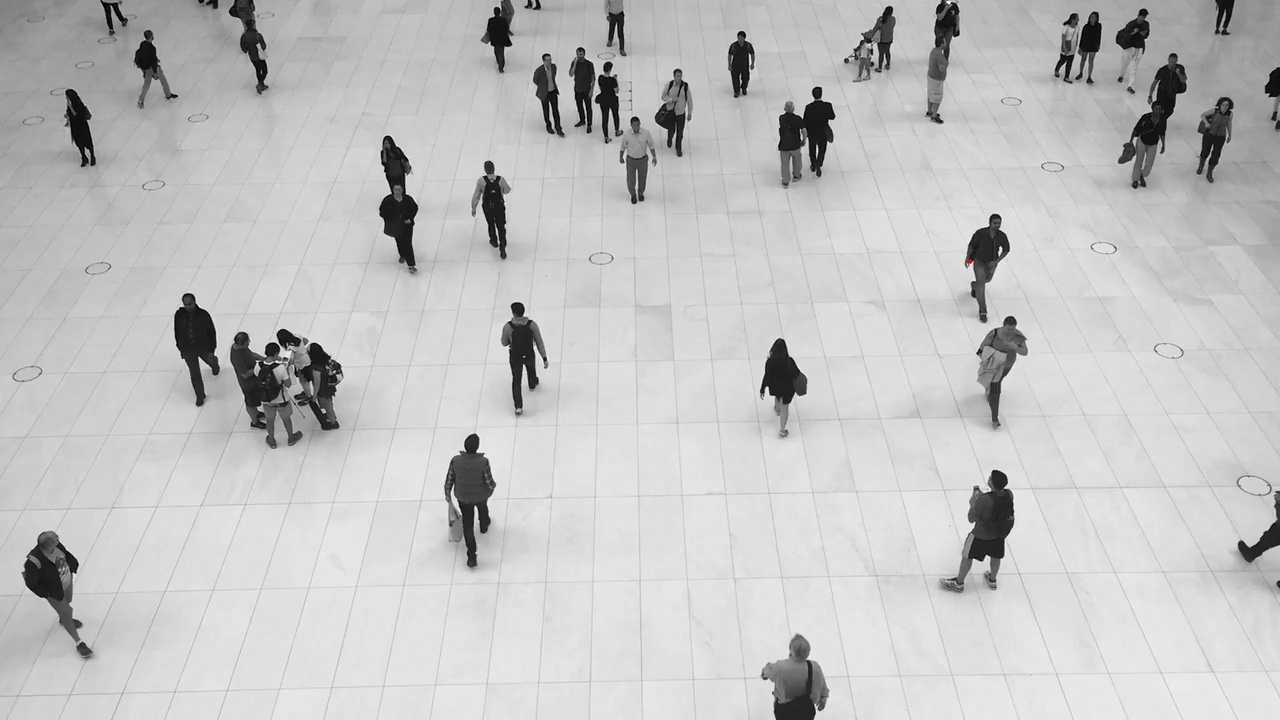

Punto final en el frame 0:

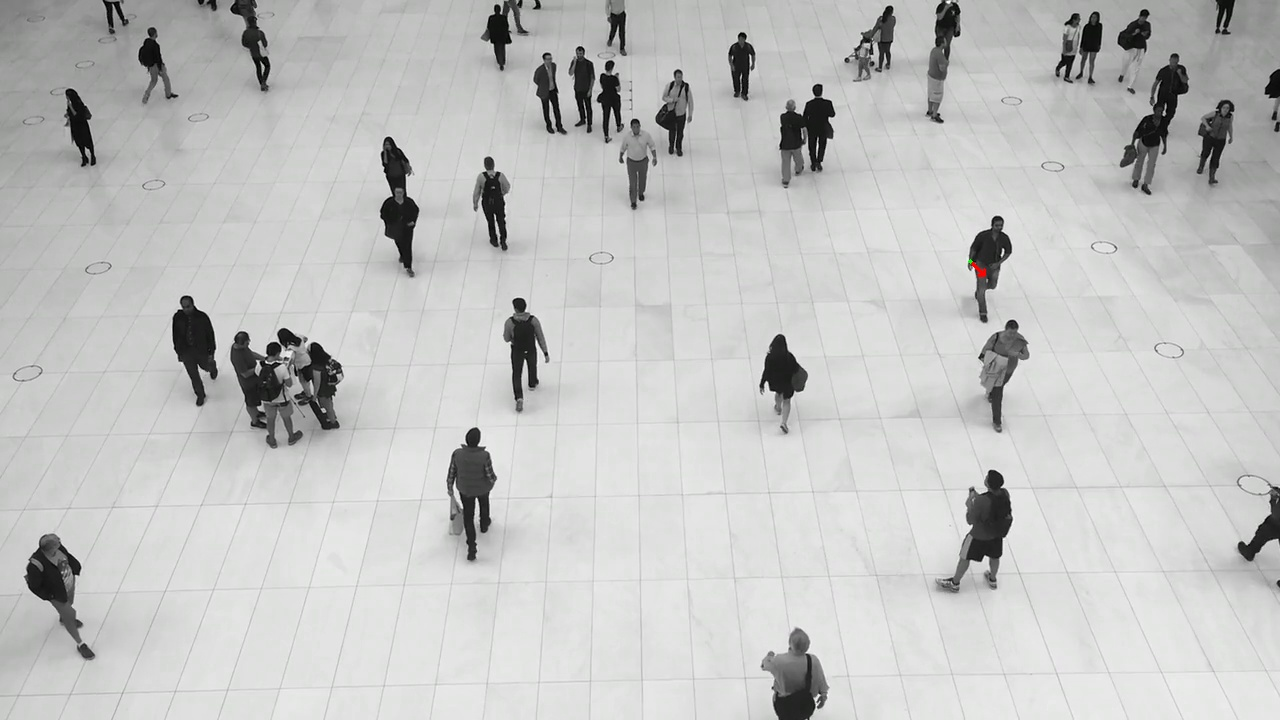

Máscara 1 en el frame 1:

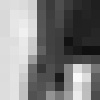

Máscara 2 en el frame 1:

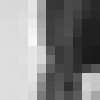

Punto inicial en el frame 1:

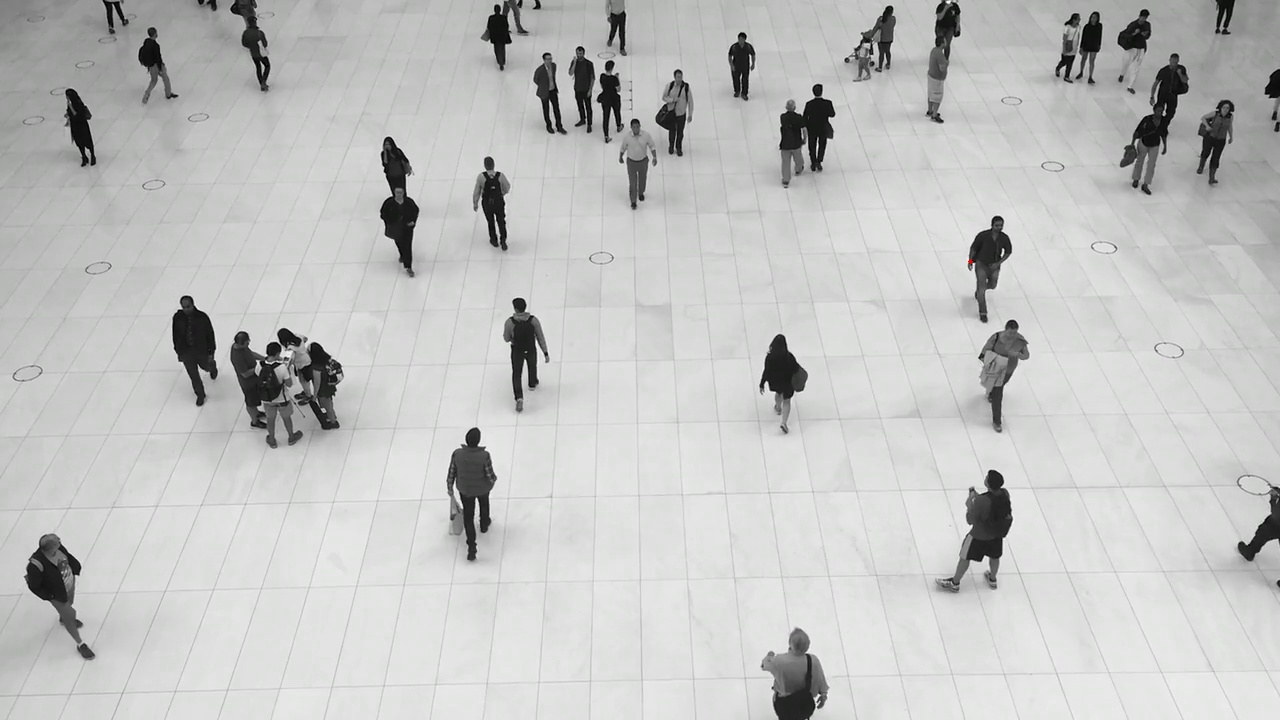

Punto final en el frame 1:

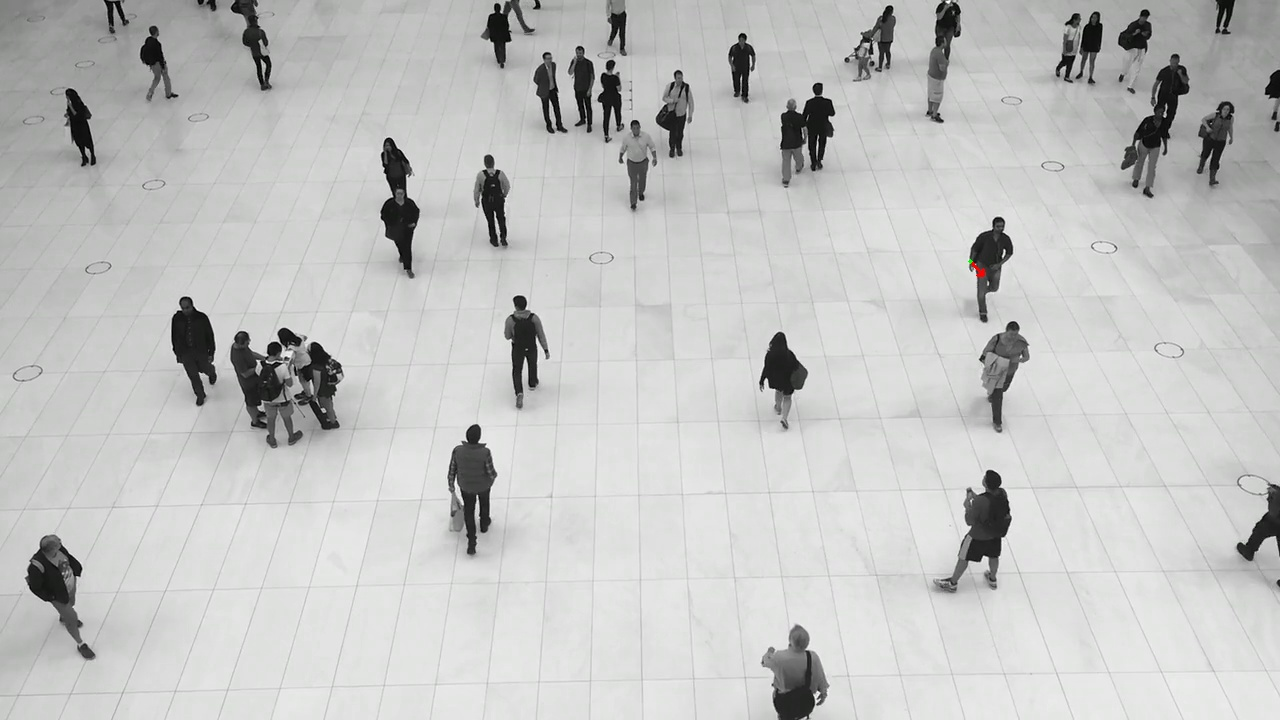

Los resultados obtenidos buscando las esquinas con Harris obtienen un buen resultado, al igual que antes. Las flechas indican la dirección correcta del movimiento.

### **Versiones anteriores**

Primera versión del código. Partimos del código proporcionado, aplicamos el preprocesado de la imagen y luego el método de Lucas-Kanade siguiendo las fórmulas.

In [ ]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/1"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5, 5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)

# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos, _) = cv2.findContours(
    canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
contornos_img = old_gray.copy()
cv2.drawContours(contornos_img, contornos, -1, (0, 0, 255), 2)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_img)

cnt = contornos[0]

# punto más arriba
top = cnt[cnt[:, :, 1].argmin()][0]
# top = (120, 85)  # una coordenada -> TODO buscar esquina (p.e.: Harris)


# Función get_mask_5x5 pedida a ChatGPT para devolver la máscara 5x5 alrededor del pixel
def get_mask_5x5(img, point):
    x, y = point

    # límites de la máscara
    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask


intensidad_1 = get_mask_5x5(old_gray, top)

print(f"Máscara 5x5:\n{intensidad_1.shape}")

sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)

# https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html
abs_grad_x = cv2.convertScaleAbs(sobelx)
abs_grad_y = cv2.convertScaleAbs(sobely)

print(f"Magnitudes en x:\n{abs_grad_x.ravel().shape}")
print(f"Magnitudes en y:\n{abs_grad_y.ravel().shape}")
matrix = np.column_stack(
    (abs_grad_x.ravel(), abs_grad_y.ravel())
)  # matrix de las derivadas
print(f"matrix:\n{matrix.shape}")
cv2.waitKey(0)
cv2.destroyAllWindows()

old_frame_copy = old_frame.copy()
cv2.circle(old_frame_copy, top, 2, (0, 0, 255), -1)
cv2.imshow("punto inicial", old_frame_copy)
cv2.imwrite(f"{out_dir}/punto_inicial_frame0.jpg", old_frame_copy)

frame_idx = 0
while status:
    if frame_idx == 2:
        break

    # captura la imagen 2
    ret, img = frame.read()
    if not ret:
        print("No hay más frames o el frame no se pudo leer.")
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    intensidad_2 = get_mask_5x5(gray, top)

    T = intensidad_2.ravel() - intensidad_1.ravel()
    print(f"matrix.T:\n{matrix.T.shape}")
    print(f"matrix:\n{matrix.shape}")
    print(f"T:\n{T.shape}")
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    top_arr = np.array(top, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")

    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 3, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)

    cv2.waitKey(0)

    frame_idx += 1

frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

Dimensiones imagen original: (720, 1280, 3)
Máscara 5x5:
(5, 5)
Magnitudes en x:
(25,)
Magnitudes en y:
(25,)
matrix:
(25, 2)
matrix.T:
(2, 25)
matrix:
(25, 2)
T:
(25,)
diff_p:
[1416.41504854  914.40533981]
old point: [822. 698.]
new_point: [2238.41504854 1612.40533981]
matrix.T:
(2, 25)
matrix:
(25, 2)
T:
(25,)
diff_p:
[1145.63280166  541.35818308]
old point: [822. 698.]
new_point: [1967.63280166 1239.35818308]


El código anterior realiza un movimiento muy brusco. ERROR

Correcciones del código anterior:
- quitar la conversión de la escala absoluta de los gradientes para que coja el signo.
- cambiar `T = intensidad_2.ravel() - intensidad_1.ravel()` a   `T = intensidad_1.ravel() - intensidad_2ravel()` siguiendo las fórmulas de las diapositivas.

In [ ]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/2"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5, 5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)

# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos, _) = cv2.findContours(
    canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
contornos_img = old_gray.copy()
cv2.drawContours(contornos_img, contornos, -1, (0, 0, 255), 2)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_img)

cnt = contornos[0]

# punto más arriba
top = cnt[cnt[:, :, 1].argmin()][0]
# top = (120, 85)  # una coordenada -> TODO buscar esquina (p.e.: Harris)


# Función get_mask_5x5 pedida a ChatGPT para devolver la máscara 5x5 alrededor del pixel
def get_mask_5x5(img, point):
    x, y = point

    # límites de la máscara
    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask


intensidad_1 = get_mask_5x5(old_gray, top)

print(f"Máscara 5x5:\n{intensidad_1.shape}")

sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)

print(f"sobelx:\n{sobelx.ravel().shape}")
print(f"sobely:\n{sobely.ravel().shape}")
matrix = np.column_stack((sobelx.ravel(), sobely.ravel()))  # matrix de las derivadas
print(f"matrix:\n{matrix.shape}")
cv2.waitKey(0)
cv2.destroyAllWindows()

old_frame_copy = old_frame.copy()
cv2.circle(old_frame_copy, top, 2, (0, 0, 255), -1)
cv2.imshow("punto inicial", old_frame_copy)
cv2.imwrite(f"{out_dir}/punto_inicial_frame0.jpg", old_frame_copy)

frame_idx = 0
while status:
    if frame_idx == 2:
        break

    # captura la imagen 2
    ret, img = frame.read()
    if not ret:
        print("No hay más frames o el frame no se pudo leer.")
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    intensidad_2 = get_mask_5x5(gray, top)

    T = intensidad_1.ravel() - intensidad_2.ravel()
    print(f"matrix.T:\n{matrix.T.shape}")
    print(f"matrix:\n{matrix.shape}")
    print(f"T:\n{T.shape}")
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    top_arr = np.array(top, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")

    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 3, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)

    cv2.waitKey(0)

    frame_idx += 1

frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

Dimensiones imagen original: (720, 1280, 3)
Máscara 5x5:
(5, 5)
sobelx:
(25,)
sobely:
(25,)
matrix:
(25, 2)
matrix.T:
(2, 25)
matrix:
(25, 2)
T:
(25,)
diff_p:
[0.29455527 0.45971541]
old point: [822. 698.]
new_point: [822.29455527 698.45971541]
matrix.T:
(2, 25)
matrix:
(25, 2)
T:
(25,)
diff_p:
[0.34675559 0.7173839 ]
old point: [822. 698.]
new_point: [822.34675559 698.7173839 ]


Ahora falta actualizar la posición del punto:

In [ ]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/3"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5, 5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)

# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos, _) = cv2.findContours(
    canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
contornos_img = old_gray.copy()
cv2.drawContours(contornos_img, contornos, -1, (0, 0, 255), 2)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_img)

cnt = contornos[0]

# punto más arriba
top = cnt[cnt[:, :, 1].argmin()][0]
# top = (120, 85)  # una coordenada -> TODO buscar esquina (p.e.: Harris)


# Función get_mask_5x5 pedida a ChatGPT para devolver la máscara 5x5 alrededor del pixel
def get_mask_5x5(img, point):
    x, y = point

    # límites de la máscara
    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask


frame_idx = 0
punto_inicial = top

while status:
    if frame_idx == 2:
        break

    intensidad_1 = get_mask_5x5(old_gray, punto_inicial)

    print(f"Máscara 5x5:\n{intensidad_1.shape}")

    sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)

    print(f"sobelx:\n{sobelx.ravel().shape}")
    print(f"sobely:\n{sobely.ravel().shape}")
    matrix = np.column_stack(
        (sobelx.ravel(), sobely.ravel())
    )  # matrix de las derivadas
    print(f"matrix:\n{matrix.shape}")
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    old_frame_copy = old_frame.copy()
    cv2.circle(old_frame_copy, punto_inicial, 2, (0, 0, 255), -1)
    cv2.imshow(f"punto inicial frame {frame_idx}", old_frame_copy)

    # captura la imagen 2
    ret, img = frame.read()
    if not ret:
        print("No hay más frames o el frame no se pudo leer.")
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    intensidad_2 = get_mask_5x5(gray, punto_inicial)

    T = intensidad_1.ravel() - intensidad_2.ravel()
    print(f"matrix.T:\n{matrix.T.shape}")
    print(f"matrix:\n{matrix.shape}")
    print(f"T:\n{T.shape}")
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    top_arr = np.array(punto_inicial, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")

    new = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 2, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)

    cv2.waitKey(0)

    punto_inicial = new_point_int
    frame_idx += 1

frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

Dimensiones imagen original: (720, 1280, 3)
Máscara 5x5:
(5, 5)
sobelx:
(25,)
sobely:
(25,)
matrix:
(25, 2)
matrix.T:
(2, 25)
matrix:
(25, 2)
T:
(25,)
diff_p:
[0.29455527 0.45971541]
old point: [822. 698.]
new_point: [822.29455527 698.45971541]
Máscara 5x5:
(5, 5)
sobelx:
(25,)
sobely:
(25,)
matrix:
(25, 2)
matrix.T:
(2, 25)
matrix:
(25, 2)
T:
(25,)
diff_p:
[0.34675559 0.7173839 ]
old point: [822. 698.]
new_point: [822.34675559 698.7173839 ]


Esquinas con Harris:

In [ ]:
import numpy as np
import cv2
import os
import numpy as np
import cv2

out_dir = "output/4"
os.makedirs(out_dir, exist_ok=True)

# frame= cv2.VideoCapture(0)
frame = cv2.VideoCapture("videos/people2.mp4")

# toma la primera imagen
status, old_frame = frame.read()
print(f"Dimensiones imagen original: {old_frame.shape}")
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
cv2.imwrite(f"{out_dir}/original.jpg", old_gray)

# Aplicar suavizado Gaussiano
gauss = cv2.GaussianBlur(old_gray, (5, 5), 0)
cv2.imwrite(f"{out_dir}/suavizado.jpg", gauss)

# Detectamos los bordes con Canny
canny = cv2.Canny(gauss, 50, 150)
cv2.imwrite(f"{out_dir}/canny.jpg", canny)

# Buscamos los contornos https://programarfacil.com/blog/vision-artificial/detector-de-bordes-canny-opencv/
(contornos, _) = cv2.findContours(
    canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
contornos_img = old_gray.copy()
cv2.drawContours(contornos_img, contornos, -1, (0, 0, 255), 2)
cv2.imwrite(f"{out_dir}/contornos.jpg", contornos_img)

cnt = contornos[0]


# Función get_mask_5x5 pedida a ChatGPT para devolver la máscara 5x5 alrededor del pixel
def get_mask_5x5(img, point):
    x, y = point

    # límites de la máscara
    x1 = max(0, x - 2)
    x2 = min(img.shape[1], x + 3)

    y1 = max(0, y - 2)
    y2 = min(img.shape[0], y + 3)

    mask = img[y1:y2, x1:x2]
    return mask


frame_idx = 0
old_frame_copy = old_frame.copy()
# Detectar esquinas con Harris
# https://programacionpython80889555.wordpress.com/2025/09/17/deteccion-de-esquinas-en-python-con-opencv-y-numpy/
dst = cv2.cornerHarris(canny, 2, 3, 0, 4)
dst = cv2.dilate(dst, None)
img2 = old_frame.copy()
esquinas = []
# https://acodigo.blogspot.com/2017/07/deteccion-de-esquinas-con-opencv.html
for y in range(0, img2.shape[0]):
    for x in range(0, img2.shape[1]):
        if dst.item(y, x) > 0.01 * dst.max():
            esquinas.append((x, y))
punto_inicial = esquinas[round(len(esquinas) / 2)]

while status:
    if frame_idx == 2:
        break

    intensidad_1 = get_mask_5x5(old_gray, punto_inicial)

    print(f"Máscara 5x5:\n{intensidad_1.shape}")

    sobelx = cv2.Sobel(intensidad_1, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(intensidad_1, cv2.CV_64F, 0, 1, ksize=3)

    print(f"sobelx:\n{sobelx.ravel().shape}")
    print(f"sobely:\n{sobely.ravel().shape}")
    matrix = np.column_stack(
        (sobelx.ravel(), sobely.ravel())
    )  # matrix de las derivadas
    print(f"matrix:\n{matrix.shape}")
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    old_frame_copy = old_frame.copy()
    cv2.circle(old_frame_copy, punto_inicial, 2, (0, 0, 255), -1)
    cv2.imshow(f"punto inicial frame {frame_idx}", old_frame_copy)

    # captura la imagen 2
    ret, img = frame.read()
    if not ret:
        print("No hay más frames o el frame no se pudo leer.")
        break

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    intensidad_2 = get_mask_5x5(gray, punto_inicial)

    T = intensidad_1.ravel() - intensidad_2.ravel()
    print(f"matrix.T:\n{matrix.T.shape}")
    print(f"matrix:\n{matrix.shape}")
    print(f"T:\n{T.shape}")
    diff_p = np.linalg.inv((matrix.T @ matrix)) @ matrix.T @ T
    print(f"diff_p:\n{diff_p}")
    top_arr = np.array(punto_inicial, dtype=np.float32)
    print(f"old point: {top_arr}")
    new_point = top_arr + diff_p
    print(f"new_point: {new_point}")

    new = img.copy()
    new2 = img.copy()
    new_point_int = (int(new_point[0]), int(new_point[1]))
    cv2.circle(new, new_point_int, 2, (0, 255, 0), -1)
    cv2.imwrite(f"{out_dir}/punto_final_frame{frame_idx}.jpg", new)
    cv2.imshow(f"punto final frame {frame_idx}", new)

    cv2.waitKey(0)

    punto_inicial = new_point_int
    frame_idx += 1

frame.release()
cv2.waitKey(0)
cv2.destroyAllWindows()

Dimensiones imagen original: (720, 1280, 3)
Máscara 5x5:
(5, 5)
sobelx:
(25,)
sobely:
(25,)
matrix:
(25, 2)
matrix.T:
(2, 25)
matrix:
(25, 2)
T:
(25,)
diff_p:
[0.26552115 0.17943085]
old point: [1213.  182.]
new_point: [1213.26552115  182.17943085]
Máscara 5x5:
(5, 5)
sobelx:
(25,)
sobely:
(25,)
matrix:
(25, 2)
matrix.T:
(2, 25)
matrix:
(25, 2)
T:
(25,)
diff_p:
[0.2535857  0.22856975]
old point: [1213.  182.]
new_point: [1213.2535857   182.22856975]


### **Lucas–Kanade: implementación de OpenCV**

En esta sección, implementamos el método de Lucas-Kanade usando el código optimizado proporcionado por [OpenCV](https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html).

In [ ]:
import numpy as np
import cv2 as cv
import os

VIDEO_PATH = "videos/people2.mp4"

cap = cv.VideoCapture(VIDEO_PATH)

# Parámetros para detectar esquinas (ShiTomasi)
feature_params = dict(maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)
# Parámetros de Lucas-Kanade
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 10, 0.03),
)
# Crear colores aleatorios
color = np.random.randint(0, 255, (100, 3))
# Primer frame
ret, old_frame = cap.read()
old_gray = cv.cvtColor(old_frame, cv.COLOR_BGR2GRAY)
# Esquinas en el primer frame
p0 = cv.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
# Crear una imagen de máscara para dibujar
mask = np.zeros_like(old_frame)
i = 0  # contador
while 1:
    ret, frame = cap.read()
    if not ret:
        break
    frame_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    # Calculamos flujo óptico (Lucas-Kanade)
    p1, st, err = cv.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
    # seleccionamos puntos válidos
    if p1 is not None:
        good_new = p1[st == 1]
        good_old = p0[st == 1]
    # Dibujamos las trayectorias
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        mask = cv.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2)
        frame = cv.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1)
    img = cv.add(frame, mask)
    cv.imshow("Lucas-Kanade (disperso)", img)
    k = cv.waitKey(30) & 0xFF
    if k == 27:
        break
    elif k == ord(
        "s"
    ):  # guardar frame si se presiona la tecla 'S' (reciclado del código de Farnebäck)
        os.makedirs("output/lk", exist_ok=True)
        cv2.imwrite(f"output/lk/lk_opencv{i}.png", img)
    # Actualizamos el frame y los puntos
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)
    i += 1

cv.destroyAllWindows()

![lk_opencv92.png](output/lk/lk_opencv92.png)

### **Farnebäck: implementación de OpenCV**

En esta sección, implementamos el método de Farnebäck. El código lo extrajimos de la página oficial de [OpenCv](https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html).

In [ ]:
import numpy as np
import cv2 as cv
import os

os.makedirs("output/farneback", exist_ok=True)
cap = cv.VideoCapture(cv.samples.findFile("videos/people2.mp4"))
ret, frame1 = cap.read()
prvs = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)
# Crear una imagen para dibujar
hsv = np.zeros_like(frame1)  # espacio de color HSV: (color, saturación, brillo)
hsv[..., 1] = 255  # fijar la saturación al máximo
while 1:
    ret, frame2 = cap.read()
    if not ret:
        print("No frames grabbed!")
        break
    next = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)
    # Calculamos flujo óptico (Farnebäck)
    flow = cv.calcOpticalFlowFarneback(prvs, next, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    # Transformar las coordenadas cartesianas a polares
    mag, ang = cv.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2  # el color indica la dirección
    hsv[..., 2] = cv.normalize(
        mag, None, 0, 255, cv.NORM_MINMAX
    )  # el brillo indica la velocidad
    bgr = cv.cvtColor(hsv, cv.COLOR_HSV2BGR)
    cv.imshow("frame2", bgr)

    k = cv.waitKey(30) & 0xFF
    if k == 27:
        break
    elif k == ord("s"):  # Guardar frame
        cv.imwrite("output/farneback/opticalfb.png", frame2)
        cv.imwrite("output/farneback/opticalhsv.png", bgr)

    prvs = next

cv.destroyAllWindows()

![opticalfb.png](output/farneback/opticalfb.png)
![opticalhsv.png](output/farneback/opticalhsv.png)

### **Diferencias: Lucas-Kanade vs. Farnebäck**
Las principales diferencias entre ambos algoritmos son las siguientes:

En primer lugar, la densidad del flujo. Farnebäck se ejecuta en todos los píxeles de la imagen mientras que Lucas-Kanade se aplica a ciertos píxeles (según se indica en la tabla 1 del [artículo](https://www.researchgate.net/publication/225138825_Two-Frame_Motion_Estimation_Based_on_Polynomial_Expansion), un 35% de densidad).

Por otro lado, tal y como se explica en la [página de OpenCV](https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html), el algoritmo implementado de Lucas-Kanade identificará un punto aunque el verdadero punto que se sigue ya haya salido de la imagen. Esto puede ocasionar ciertos errores en el seguimiento de objetos. Esto en Farnebäck no ocurre, ya que este método evaluará los cambios en todos los píxeles de la imagen y dibujará en función de la dirección y la magnitud de cada uno. Por tanto, Lucas-Kanade, al ser disperso, se vuelve dependiente de las características de la imagen e inestable a cambios de intensidad, mientras que Farnebäck es más robusto en estos casos.

Por último, Lucas-Kanade es más preciso a la hora de detectar los bordes mientras realiza el seguimiento, pues las trayectorias obtenidas son más limpias y definidas. En cambio, con Farnebäck, los cambios de intensidades se ven difuminados debido a las aproximaciones de los vecinos mediante los polinomios cuadráticos, según se explica en el [artículo](https://www.researchgate.net/publication/225138825_Two-Frame_Motion_Estimation_Based_on_Polynomial_Expansion).

### **Conclusión**
Atendiendo a los resultados obtenidos, podemos observar que Lucas-Kanade es capaz de seguir la trayectoria de varios puntos en un vídeo con precisión. Estos puntos corresponden a partes del cuerpo de las personas. Por otro lado, Farnebäck consigue mostrar el flujo de la imagen diferenciando por colores y brillo.

Por tanto, Lucas-Kanade es ideal si queremos seguir un punto en un vídeo o imagen mientras que Farnebäck es preferible si queremos observar cómo se mueven los objetos en un vídeo o imagen.

## **Flujo óptico: Lucas–Kanade vs. Farnebäck vs.  RAFT y evaluación**

La métrica seleccionada para evaluar los distintos métodos es el **End-Point-Error (EPE)**, que es la distancia euclídea promedio entre el flujo predicho y el ground truth (flujo real). 


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
from torchvision.models.optical_flow import raft_large
from torchvision.utils import flow_to_image
import torch.nn.functional as F

In [2]:
IMG1_PATH = "flying_chairs/00001_img1.ppm"
IMG2_PATH = "flying_chairs/00001_img2.ppm"
FLOW_GT_PATH = "flying_chairs/00001_flow.flo"

La función para leer los archivos .flo se la pedimos a ChatGPT.

In [3]:
def read_flow(f):
    """Lee el archivo .flo y devuelve el array (H, W, 2)."""
    with open(f, "rb") as f:
        np.fromfile(f, np.float32, count=1)
        w, h = np.fromfile(f, np.int32, count=2)
        flow = np.fromfile(f, np.float32, count=2 * w * h)
    return flow.reshape((h, w, 2))

La siguiente función calcula el End-Point-Error (EPE). Fuente: [A Database and Evaluation Methodology for Optical Flow](https://vision.middlebury.edu/flow/floweval-ijcv2011.pdf) (pág.16)


In [5]:
def get_epe(pred, gt):
    """Calcula el End-Point-Error (EPE)."""
    diff = pred - gt
    epe = np.mean(np.sqrt(diff[:, :, 0] ** 2 + diff[:, :, 1] ** 2))
    return epe

### **Evaluación con End-Point-Error (EPE)**
#### **Lucas-Kanade**

Adaptamos el código de [OpenCV](https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html) a una función para que, pasándole las dos imágenes a comparar, calcule el flujo de Lucas-Kanade.

In [5]:
def lk_flow(img1, img2):
    """Calcula el flujo óptico con Lucas-Kanade."""
    old_gray = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    frame_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

    H, W = old_gray.shape

    # Parámetros para detectar esquinas (buenos puntos a seguir)
    feature_params = dict(maxCorners=500, qualityLevel=0.3, minDistance=7, blockSize=7)

    # Parámetros de Lucas-Kanade
    lk_params = dict(
        winSize=(15, 15),
        maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03),
    )

    # Detectamos esquinas en img1
    p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

    # Para guardar flujo predicho
    flow_pred = np.zeros((H, W, 2), dtype=np.float32)

    mask = np.zeros_like(img2)
    view = img2.copy()

    if p0 is None:
        return flow_pred, view

    # Calculamos flujo óptico (Lucas-Kanade) en img2
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    if p1 is None:
        return flow_pred, view

    # Filtrar solo los puntos válidos
    good_new = p1[st == 1]
    good_old = p0[st == 1]

    # Dibujamos las trayectorias
    for new_pt, old_pt in zip(good_new, good_old):
        x_new, y_new = new_pt.ravel()
        x_old, y_old = old_pt.ravel()

        # Almacenar flujo (dx, dy)
        flow_pred[int(y_old), int(x_old)] = [x_new - x_old, y_new - y_old]

        mask = cv2.line(
            mask, (int(x_old), int(y_old)), (int(x_new), int(y_new)), (0, 255, 0), 2
        )
        view = cv2.circle(view, (int(x_new), int(y_new)), 3, (0, 0, 255), -1)

    view = cv2.add(view, mask)

    return flow_pred, view

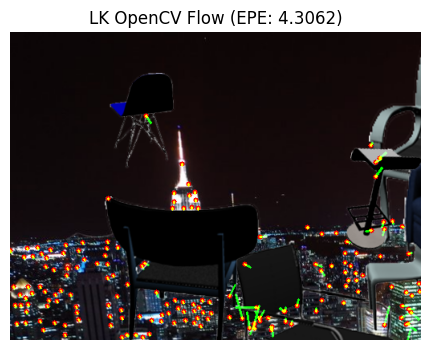

Resultado EPE (Lucas-Kanade OpenCV): 4.3062 píxeles/frame.


In [6]:
# Carga de datos
gt_flow = read_flow(FLOW_GT_PATH)
img1 = cv2.cvtColor(cv2.imread(str(IMG1_PATH)), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(str(IMG2_PATH)), cv2.COLOR_BGR2RGB)

# Calcular Flujo Lucas-Kanade
flow_pred, img_wiew = lk_flow(img1, img2)

# Calcular EPE
epe_lk = get_epe(flow_pred, gt_flow)

display = cv2.cvtColor(img_wiew, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 4))
plt.imshow(display)
plt.title(f"LK OpenCV Flow (EPE: {epe_lk:.4f})")
plt.axis("off")
plt.show()

print(f"Resultado EPE (Lucas-Kanade OpenCV): {epe_lk:.4f} píxeles/frame.")

#### **Farnebäck**

La siguiente función se ha obtenido adaptando el código proporcionado por [OpenCV](https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html) para calcular el flujo óptico con Farnebäck. El principal cambio es la adaptación del cálculo a solo dos frames, en vez de a un vídeo completo.

In [7]:
def farneback_flow(img1, img2):
    """Calcula el flujo óptico con Farnebäck."""
    old_gray = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    frame_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    
    # Calculamos flujo óptico (Farnebäck)
    flow = cv2.calcOpticalFlowFarneback(old_gray, frame_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)

    # Crear una imagen para dibujar
    hsv = np.zeros_like(img1)  # espacio de color HSV: (color, saturación, brillo)
    hsv[..., 1] = 255  # fijar la saturación al máximo

    # Transformar las coordenadas cartesianas a polares
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2  # el color indica la dirección
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)  # el brillo indica la velocidad

    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    view = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    return flow, view


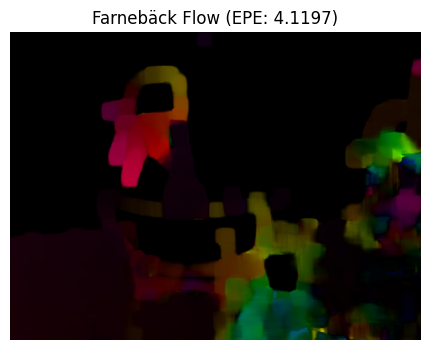

EPE Farnebäck: 4.1197 píxeles/frame.


In [8]:
# Carga de datos
gt_flow = read_flow(FLOW_GT_PATH)
img1 = cv2.cvtColor(cv2.imread(str(IMG1_PATH)), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(str(IMG2_PATH)), cv2.COLOR_BGR2RGB)

# Calcular Flujo Farnebäck
flow_pred, img_wiew = farneback_flow(img1, img2)

# Calcular EPE
epe_f = get_epe(flow_pred, gt_flow)

display = cv2.cvtColor(img_wiew, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 4))
plt.imshow(display)
plt.title(f"Farnebäck Flow (EPE: {epe_f:.4f})")
plt.axis("off")
plt.show()

print(f"EPE Farnebäck: {epe_f:.4f} píxeles/frame.")

#### **RAFT**

In [9]:
def preprocess(batch):
    transforms = T.Compose(
        [
            T.ConvertImageDtype(torch.float32),
            T.Normalize(mean=0.5, std=0.5),  # pasa [0, 1] a [-1, 1]
        ]
    )
    batch = transforms(batch)
    return batch


def raft_flow(img1, img2):
        
    tensor_img1 = torch.from_numpy(img1)
    tensor_img2 = torch.from_numpy(img2)

    # Solución de ChatGPT para solucionar problema con canales
    tensor1 = tensor_img1.permute(2, 0, 1)
    tensor2 = tensor_img2.permute(2, 0, 1)

    #usamos cuda para ir más rapido
    device = "cuda" if torch.cuda.is_available() else "cpu"

    #preprocesamos la imagen
    # Solución de ChatGPT para solucionar problema con canales
    img1_batch = preprocess(tensor1).unsqueeze(0).to(device)
    img2_batch = preprocess(tensor2).unsqueeze(0).to(device)
    
    model = raft_large(pretrained=True, progress=False).to(device)
    model = model.eval()

    list_of_flows = model(img1_batch.to(device), img2_batch.to(device))
    predicted_flows = list_of_flows[-1]

    flow_imgs = flow_to_image(predicted_flows)

    return predicted_flows, flow_imgs


c:\Users\chess\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\chess\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Raft_Large_Weights.C_T_SKHT_V2`. You can also use `weights=Raft_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


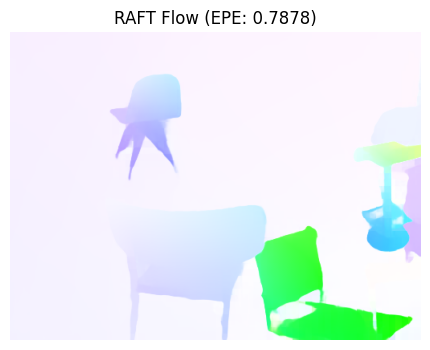

EPE RAFT: 0.7878 píxeles/frame.


In [10]:
# Carga de datos
gt_flow = read_flow(FLOW_GT_PATH)
img1 = cv2.cvtColor(cv2.imread(str(IMG1_PATH)), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(str(IMG2_PATH)), cv2.COLOR_BGR2RGB)

# Calcular Flujo RAFT
flow_pred, img_wiew = raft_flow(img1, img2)

flow_pred = flow_pred[0].permute(1, 2, 0).detach().cpu().numpy() # Solución de ChatGPT para solucionar problema con canales

# Calcular EPE
epe_raft = get_epe(flow_pred, gt_flow)

display = img_wiew[0].permute(1, 2, 0).detach().cpu().numpy() # Solución de ChatGPT para solucionar problema con canales
plt.figure(figsize=(8, 4))
plt.imshow(display)
plt.title(f"RAFT Flow (EPE: {epe_raft:.4f})")
plt.axis("off")
plt.show()

print(f"EPE RAFT: {epe_raft:.4f} píxeles/frame.")


#### **Conclusiones**

In [11]:
print(f"EPE Lucas-Kanade: {epe_lk:.4f} píxeles/frame.")
print(f"EPE Farnebäck: {epe_f:.4f} píxeles/frame.")
print(f"EPE RAFT: {epe_raft:.4f} píxeles/frame.")

EPE Lucas-Kanade: 4.3062 píxeles/frame.
EPE Farnebäck: 4.1197 píxeles/frame.
EPE RAFT: 0.7878 píxeles/frame.


El mejor resultado obtenido con la métrica EPE es el de RAFT, que tiene muy buen rendimiento al tratarse de un modelo de aprendizaje profundo basado en unidades recurrentes (GRUs), con un error de 0.7878 píxeles/frame. Seguidamente, se encuentra el algoritmo de Farnebäck, con un error de 4.1197 píxeles/frame. Esto se debe a que difumina el movimiento mediante la expansión polinomial y pierde precisión. Y finalmente, el algoritmo con peor rendimiento según la métrica EPE es Lucas-Kanade, con un error de 4.3062 píxeles/frame. Esto se debe a que este algoritmo es disperso y solo tiene en cuenta unos cuantos píxeles, no toda la imagen, por lo que gran parte de ella se quedará sin procesar.

### **Evaluación del tiempo de ejecución**
Utilizamos los códigos anteriores y almacenamos los tiempos de ejecución del modelo, medidos con la librería `time`, en una lista. Posteriormente, se sumarán y se compararán.
#### **Lucas-Kanade**

In [5]:
import numpy as np
import cv2 as cv
import os
import time

VIDEO_PATH = "videos/people2.mp4"

cap = cv.VideoCapture(VIDEO_PATH)

feature_params = dict(maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 10, 0.03),
)

color = np.random.randint(0, 255, (100, 3))
ret, old_frame = cap.read()
old_gray = cv.cvtColor(old_frame, cv.COLOR_BGR2GRAY)
p0 = cv.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
mask = np.zeros_like(old_frame)
i = 0
time_list_lk = [] # lista para guardar tiempos de ejecución

while 1:
    ret, frame = cap.read()
    if not ret:
        break
    frame_gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    t1 = time.time() # tiempo inicio
    p1, st, err = cv.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
    t2 = time.time() # tiempo fin
    time_list_lk.append(t2-t1) # añadir tiempo de ejecución

    if p1 is not None:
        good_new = p1[st == 1]
        good_old = p0[st == 1]
        
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel()
        c, d = old.ravel()
        mask = cv.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2)
        frame = cv.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1)
    img = cv.add(frame, mask)
    cv.imshow("Lucas-Kanade (disperso)", img)
    k = cv.waitKey(30) & 0xFF
    if k == 27:
        break
    elif k == ord(
        "s"
    ):
        os.makedirs("output/lk", exist_ok=True)
        cv2.imwrite(f"output/lk/lk_opencv{i}.png", img)

    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)
    i += 1

cv.destroyAllWindows()

#### **Farnebäck**

In [8]:
import numpy as np
import cv2 as cv
import os

os.makedirs("output/farneback", exist_ok=True)
cap = cv.VideoCapture(cv.samples.findFile("videos/people2.mp4"))
ret, frame1 = cap.read()
prvs = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)

hsv = np.zeros_like(frame1)
hsv[..., 1] = 255
time_list_f = [] # lista para guardar tiempos de ejecución

while 1:
    ret, frame2 = cap.read()
    if not ret:
        print("No frames grabbed!")
        break
    next = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)

    t1 = time.time() # tiempo inicio
    flow = cv.calcOpticalFlowFarneback(prvs, next, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    t2 = time.time() # tiempo fin
    time_list_f.append(t2-t1) # añadir tiempo de ejecución

    mag, ang = cv.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv.normalize(
        mag, None, 0, 255, cv.NORM_MINMAX
    )
    bgr = cv.cvtColor(hsv, cv.COLOR_HSV2BGR)
    cv.imshow("frame2", bgr)

    k = cv.waitKey(30) & 0xFF
    if k == 27:
        break
    elif k == ord("s"):
        os.makedirs("output/farneback", exist_ok=True)
        cv.imwrite("output/farneback/opticalfb.png", frame2)
        cv.imwrite("output/farneback/opticalhsv.png", bgr)

    prvs = next

cv.destroyAllWindows()

No frames grabbed!


#### **RAFT**

In [6]:
import numpy as np
import cv2 as cv
import os

def preprocess(batch):
    transforms = T.Compose(
        [
            T.ConvertImageDtype(torch.float32),
            T.Normalize(mean=0.5, std=0.5),
        ]
    )
    batch = transforms(batch)
    return batch


def raft_flow(img1, img2, model, device, time_list_raft):
        
    tensor_img1 = torch.from_numpy(img1)
    tensor_img2 = torch.from_numpy(img2)

    tensor1 = tensor_img1.permute(2, 0, 1)
    tensor2 = tensor_img2.permute(2, 0, 1)

    model = model.eval()
    
    img1_batch = preprocess(tensor1).unsqueeze(0).to(device)
    img2_batch = preprocess(tensor2).unsqueeze(0).to(device)
    

    t1 = time.time() # tiempo inicio
    with torch.no_grad(): # sugerencia de ChatGPT para acelerar el tiempo de ejecución
        list_of_flows = model(img1_batch.to(device), img2_batch.to(device))
    t2 = time.time() # tiempo fin
    time_list_raft.append(t2 - t1) # añadir tiempo de ejecución
    predicted_flows = list_of_flows[-1]

    flow_imgs = flow_to_image(predicted_flows)

    return predicted_flows, flow_imgs



VIDEO_PATH = "videos/people2.mp4"

cap = cv.VideoCapture(VIDEO_PATH)

ret, old_frame = cap.read()
img1 = cv.cvtColor(old_frame, cv.COLOR_BGR2RGB)
mask = np.zeros_like(old_frame)
i = 0
time_list_raft = [] # lista para guardar tiempos de ejecución

# Sacamos el modelo para ir más rápido (sugerencia de ChatGPT)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = raft_large(pretrained=True, progress=False).to(device)

while 1:
    ret, frame = cap.read()
    if not ret:
        break
    img2 = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    flow_pred, img_wiew = raft_flow(img1, img2, model, device, time_list_raft)
    flow_pred = flow_pred[0].permute(1, 2, 0).detach().cpu().numpy()
    display = img_wiew[0].permute(1, 2, 0).detach().cpu().numpy()
    cv.imshow("RAFT", display)
    img1 = img2

    k = cv.waitKey(30) & 0xFF
    if k == 27:
        break
    elif k == ord("s"):
        os.makedirs("output/raft", exist_ok=True)
        cv.imwrite("output/raft/opticalfb.png", display)
        


cv.destroyAllWindows()

EL flujo óptico con RAFT obtiene la siguiente visualización:

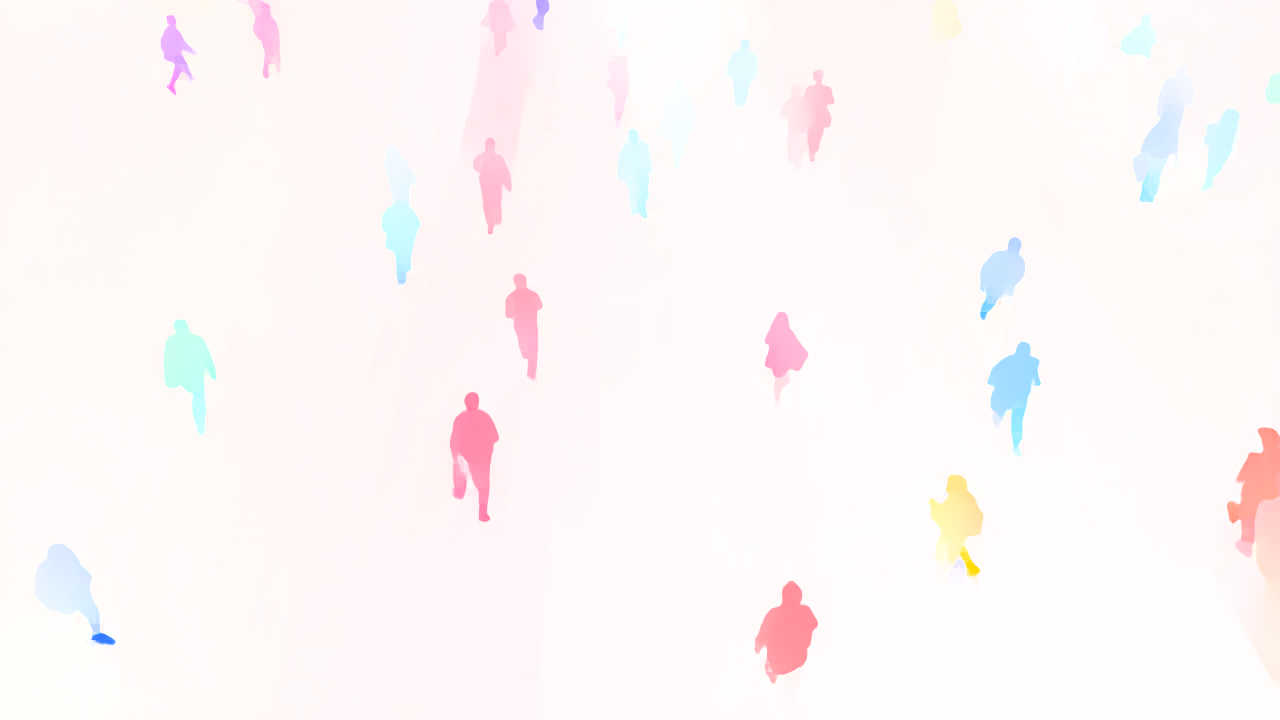

#### **Conclusiones**

In [15]:
print(f"Tiempo ejecución Lucas-Kanade: {sum(time_list_lk)}")
print(f"Tiempo ejecución Farnebäck: {sum(time_list_f)}")
print(f"Tiempo ejecución RAFT: {sum(time_list_raft)}")

Tiempo ejecución Lucas-Kanade: 0.31751394271850586
Tiempo ejecución Farnebäck: 44.1784987449646
Tiempo ejecución RAFT: 116.30114531517029


Atendiendo a los tiempos de ejecución de cada algoritmo, podemos concluir que el de Lucas-Kanade es el más rápido con gran diferencia, con un tiempo de 0.318 segundos. Esto se debe a que, aparte de estar optimizado por OpenCV, su implementación es dispersa, no se realiza para todos los puntos. Seguidamente, se encuentra el de Farnebäck, con un tiempo de 44.178 segundos. Este método también está optimizado por OpenCV pero tarda más que Lucas-Kanade debido a que es un algoritmo denso, es decir, se realiza para todos los píxeles. Por último, se encuentra el algoritmo de RAFT, que debido a que tiene que cargar el modelo de aprendizaje profundo basado en unidades recurrentes (GRU) que conlleva un alto costo computacional (116.301).

## **Seguimiento de objetos: YOLO vs. Lucas-Kanade**

### **YOLO: Detección y seguimiento de muñeca mediante distancias**
Pasos a seguir:
1. Detectar una muñeca con YOLO.
2. Realizar el seguimiento de la muñeca seleccionada mediante distancias.

Para llevar a cabo esta tarea, seleccionamos la primera muñeca derecha (`ID=10`) detectada con YOLO. 

Utilizamos la variable `punto_base` para almacenar el punto de partida de cada frame y la variable `history_dist` para almacenar las distancias de las muñecas detectadas durante la reproducción del vídeo. Luego, si no se ha detectado ninguna muñeca aún, se almacena en `punto_base` la primera muñeca detectada. Seguidamente, se guardan las distancias entre los puntos detectados con YOLO y el punto de referencia. 

Una vez recorridos todos los puntos detectados, se ordenan las distancias de dichos puntos y se escoge el mejor resultado: el punto con la menor distancia. Luego, si aún no hay resultados o la máxima distancia es nula, se añade el resultado obtenido. En caso contrario, se comprueba primero que la distancia al punto base del nuevo resultado sea, como mucho, 1.8 veces la máxima distancia encontrada. En el caso de ninguno de los puntos detectados cumpla esta condición, se añade el punto `(0,0)`, indicando que no se ha detectado la muñeca.

In [1]:
import cv2
import numpy as np
import math
import os
from ultralytics import YOLO


model = YOLO("yolo11x-pose.pt")
video = cv2.VideoCapture("videos/people2.mp4")

success, frame = video.read()
size = (frame.shape[1], frame.shape[0])
fourcc = cv2.VideoWriter_fourcc(*"DIVX")
video_out = cv2.VideoWriter("output/yolo_pose.mp4", fourcc, 30.0, size)

# Variable para guardar el punto base
punto_base = None
# Variable para guardar el historial de las distancias entre los puntos nuevos y el punto de referencia
history_dist = []
# Variable para guardar el historial de puntos detectados
history_points = []

# Crear una imagen de máscara para dibujar
mask = np.zeros_like(frame)
i = 0  # contador

while success:
    puntos = []
    dist_ptos = (
        []
    )  # Variable para guardar las distancias de todos los puntos detectados en un frame

    results = model.track(frame, verbose=False)[0]

    for r in results:
        kpts = r.keypoints
        keypoint = kpts.xy[0, 10]  # ID = 10 (muñeca derecha)
        x, y = (int(keypoint[0])), (int(keypoint[1]))

        ####
        # Este código es de invención propia
        ####
        # Si aún no hay punto de referencia, coge el primero que detecta YOLO
        if punto_base is None:
            punto_base = keypoint
            cv2.circle(frame, (x, y), 5, (0, 0, 255), -1)
        # Calcula la distancia entre el punto de referencia y el punto detectado
        dist_temp = math.dist(punto_base, keypoint)  # función buscada en Google
        # Se guarda la distancia en la lista
        dist_ptos.append((keypoint, dist_temp))
    # Se escoge el punto con menor distancia
    mejor = sorted(dist_ptos, key=lambda x: x[1])[0]

    if len(history_dist) != 0 and sum(history_dist) != 0:
        # Si la distancia es, como mucho, 1.8 veces la mayor distancia
        # de las distancias del historial, se toma como punto bueno
        if mejor[1] < max(history_dist) * 1.8:
            punto_base = mejor[0]
            history_points.append(punto_base)
            history_dist.append(mejor[1])
            # Dibujamos las trayectorias (código reciclado de Lucas-Kanade)
            if (int(history_points[-2][0]), int(history_points[-2][1])) != (
                0,
                0,
            ):  # dibujar línea solo si se ha detectado un punto anteriormente
                mask = cv2.line(
                    mask,
                    (int(mejor[0][0]), int(mejor[0][1])),
                    (int(history_points[-2][0]), int(history_points[-2][1])),
                    (0, 255, 0),
                    2,
                )
            frame = cv2.circle(
                frame, (int(mejor[0][0]), int(mejor[0][1])), 3, (0, 0, 255), -1
            )

        else:
            # No se detecta, por tanto, ponemos a (0,0)
            history_points.append((0, 0))
    else:
        # Añadir los primeros puntos (len(history_dist) == 0 o sum(history_dist) == 0)
        punto_base = mejor[0]
        history_points.append(punto_base)
        history_dist.append(mejor[1])
        if len(history_points) > 1:  # si hay al menos 2 puntos para graficar la línea
            mask = cv2.line(
                mask,
                (int(mejor[0][0]), int(mejor[0][1])),
                (int(history_points[-2][0]), int(history_points[-2][1])),
                (0, 255, 0),
                2,
            )
        cv2.circle(frame, ((int(mejor[0][0])), (int(mejor[0][1]))), 5, (0, 0, 255), -1)

    ####
    # Mostrar el fotograma anotado
    img = cv2.add(frame, mask)
    cv2.imshow("YOLO", img)
    video_out.write(img)
    success, frame = video.read()
    key = cv2.waitKey(30) & 0xFF
    if key == 27:
        break
    elif key == ord(
        "s"
    ):  # guardar frame si se presiona la tecla 'S' (reciclado del código de Farnebäck)
        os.makedirs("output/yolo", exist_ok=True)
        cv2.imwrite(f"output/yolo/yolo_frame{i}.png", img)
    i += 1


# Liberar el objeto de captura de video y cerrar la ventana de visualización
video.release()
video_out.release()
cv2.destroyAllWindows()

Graficamos las coordenadas X e Y con respecto al tiempo (medido en frames):

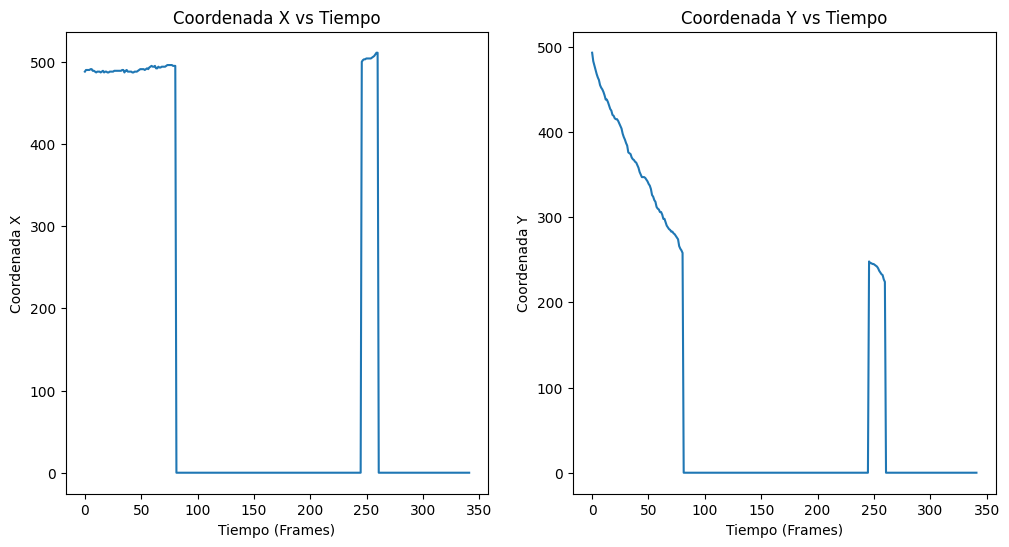

In [2]:
####
# Este código es de invención propia
####

import matplotlib.pyplot as plt

t1 = np.linspace(0, len(history_points), num=len(history_points))
x1_points = []
y1_points = []
for point in history_points:
    x1_points.append(int(point[0]))
    y1_points.append(int(point[1]))

plt.figure(1, (12, 6))
plt.subplot(1, 2, 1)
plt.plot(t1, x1_points)
plt.ylabel("Coordenada X")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada X vs Tiempo")
plt.subplot(1, 2, 2)
plt.plot(t1, y1_points)
plt.ylabel("Coordenada Y")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada Y vs Tiempo")
plt.show()

En las gráficas se observa que en un principio la detección de la muñeca se realiza correctamente. También se puede observar en el vídeo:
![yolo_frame62.png](output/yolo/yolo_frame62.png)

Luego, hay varios frames en los que no detecta la muñeca. Esto ocurre porque o en un frame no se detecta la muñeca o no cumple la condición de que, como mucho, la distancia entre el nuevo punto y el de referencia sea 1.8 veces la máxima distancia detectada. Al no detectar un frame, las probabilidades de que la siguiente detección cumpla la condición es menor. Se puede ver en la siguiente imagen que la detección de la muñeca falló en un punto y no se volvió a cumplir la condición para que se detectase de nuevo:
![yolo_frame117.png](output/yolo/yolo_frame117.png)

Finalmente, en las gráficas observamos que tras varios frames sin detección, se vuelve a detectar una muñeca. En el vídeo vemos que una persona distinta pasa por el mismo sitio donde se quedó la última detección de la muñeca. Por lo tanto, se trataría de un error del algoritmo diseñado.
![yolo_frame254.png](output/yolo/yolo_frame254.png)


### **YOLO + Lucas-Kanade: Detección y seguimiento de muñeca**
Pasos a seguir:
1. Detectar una muñeca con YOLO.
2. Realizar el seguimiento de la muñeca seleccionada con Lucas-Kanade.

Para llevar a cabo esta tarea, seleccionamos la primera muñeca derecha (`ID=10`) detectada con YOLO. 

Utilizamos la variable `p0` para almacenar las coordenadas del primer frame de la muñeca a detectar y la variable `history_points` para almacenar los puntos para luego graficarlos. 

Una vez detectada la muñeca, seguimos el punto con la implementación de Lucas-Kanade de OpenCV.

In [3]:
import cv2
import numpy as np
import os
from ultralytics import YOLO

VIDEO_PATH = "videos/people2.mp4"

video = cv2.VideoCapture(VIDEO_PATH)

# Model
model = YOLO("yolo11x-pose.pt")

# Parámetros para detectar esquinas (ShiTomasi)
feature_params = dict(maxCorners=500, qualityLevel=0.3, minDistance=7, blockSize=7)
# Parámetros de Lucas-Kanade
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03),
)
# Primer frame
ret, old_frame = video.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

p0 = None
# Variable para guardar el historial de puntos detectados
history_points = []

results = model.track(old_frame, verbose=False)[0]
for r in results:
    if p0 is None:
        kpts = r.keypoints
        keypoint = kpts.xy[0, 10]  # ID = 10 (muñeca derecha)
        x, y = (int(keypoint[0])), (int(keypoint[1]))
        p0 = np.array((x, y)).reshape(
            -1, 1, 2
        )  # Dimensiones para la función cv2.calcOpticalFlowPyrLK (se obtuvo del código de OpenCV)
        p0 = np.float32(
            p0
        )  # Corrección de Gemini para solventar problema de tipo de datos en cv2.calcOpticalFlowPyrLK
        history_points.append(p0)
        break

# Crear una imagen de máscara para dibujar
mask = np.zeros_like(old_frame)
i = 0  # contador
while True:
    ret, frame = video.read()
    if not ret:
        break
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # Calculamos flujo óptico (Lucas-Kanade)
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
    if p1 is None:
        break
    # seleccionamos puntos válidos
    good_new = p1[st == 1]
    good_old = p0[st == 1]
    history_points.append(good_new)
    # Dibujamos las trayectorias
    for new, old in zip(good_new, good_old):
        x_new, y_new = new.ravel()
        x_old, y_old = old.ravel()
        mask = cv2.line(
            mask, (int(x_new), int(y_new)), (int(x_old), int(y_old)), (0, 255, 0), 2
        )
        frame = cv2.circle(frame, (int(x_new), int(y_new)), 3, (0, 0, 255), -1)
    img = cv2.add(frame, mask)
    cv2.imshow("YOLO + Lucas-Kanade", img)
    key = cv2.waitKey(30) & 0xFF
    if key == 27:
        break
    elif key == ord(
        "s"
    ):  # guardar frame si se presiona la tecla 'S' (reciclado del código de Farnebäck)
        os.makedirs("output/yolo", exist_ok=True)
        cv2.imwrite(f"output/yolo/yolo_lk_frame{i}.png", img)
    # Actualizamos
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)
    i += 1

cv2.destroyAllWindows()

Usamos Gemini para resolver el siguiente problema:
```bash
---------------------------------------------------------------------------
error                                     Traceback (most recent call last)
Cell In[22], line 52
     50 frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
     51 # Calculamos flujo óptico (Lucas-Kanade)
---> 52 p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)
     53 if p1 is None:
     54     break

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1281: error: (-215:Assertion failed) (npoints = prevPtsMat.checkVector(2, CV_32F, true)) >= 0 in function 'cv::`anonymous-namespace'::SparsePyrLKOpticalFlowImpl::calc'
```

A continuación, graficamos las coordenadas X e Y con respecto al tiempo:

341


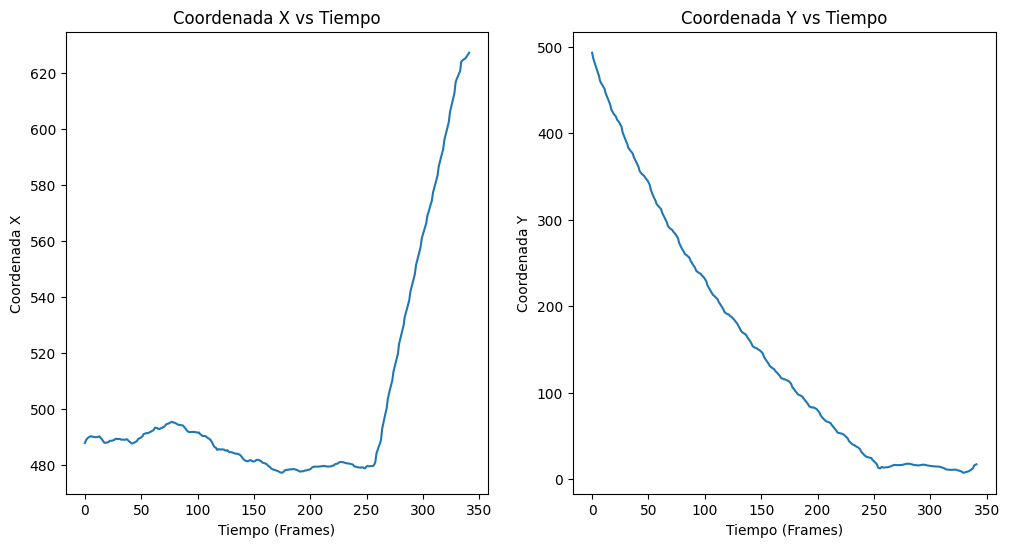

In [4]:
####
# Este código es de invención propia
####

import matplotlib.pyplot as plt

t2 = np.linspace(0, len(history_points), num=len(history_points))
x2_points = []
y2_points = []
for point in history_points:
    x2_points.append(point.reshape(-1)[0])
    y2_points.append(point.reshape(-1)[1])

print(len(history_points))
plt.figure(1, (12, 6))
plt.subplot(1, 2, 1)
plt.plot(t2, x2_points)
plt.ylabel("Coordenada X")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada X vs Tiempo")
plt.subplot(1, 2, 2)
plt.plot(t2, y2_points)
plt.ylabel("Coordenada Y")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada Y vs Tiempo")
plt.show()

Atentiendo a las gráficas obtenidas, concluimos que al realizar el seguimiento de la muñeca con Lucas-Kanade se obtienen mejores resultados, pues el seguimiento se realiza correctamente hasta que la persona sale de la imagen. La siguiente imagen muestra el correcto seguimiento:

![yolo_lk_frame217.png](output/yolo/yolo_lk_frame217.png)

No obtante, cuando la persona ya no está en la imagen, Lucas-Kanade sigue otro punto que se cruza y, por eso, pasados los 250 frames, la coordenada X aumenta drásticamente. Esto se puede observar en la siguiente imagen:

![yolo_lk_frame317.png](output/yolo/yolo_lk_frame317.png)

Unificamos las gráficas:

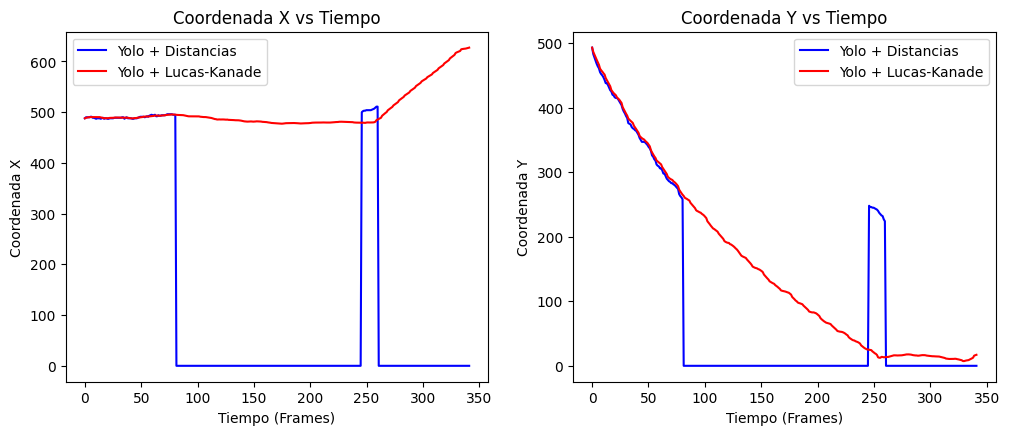

In [24]:
plt.figure(1, (12, 10))
plt.subplot(2, 2, 1)
plt.plot(t1, x1_points, label="Yolo + Distancias", color="b")
plt.plot(t2, x2_points, label="Yolo + Lucas-Kanade", color="r")
plt.ylabel("Coordenada X")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada X vs Tiempo")
plt.legend(loc="upper left")
plt.subplot(2, 2, 2)
plt.plot(t1, y1_points, label="Yolo + Distancias", color="b")
plt.plot(t2, y2_points, label="Yolo + Lucas-Kanade", color="r")
plt.ylabel("Coordenada Y")
plt.xlabel("Tiempo (Frames)")
plt.title("Coordenada Y vs Tiempo")
plt.legend()
plt.show()

En las gráficas anteriores podemos comparar mejor el funcionamiento de ambos métodos.

En la primera fase, donde ambos métodos siguen la muñeca correctamente, vemos que las coordenadas difieren poco, es decir, la detección es casi igual. Luego, podemos observar que Lucas-Kanade continúa con el seguimiento hasta que la persona sale de la imagen.

Por tanto, concluimos que Lucas-Kanade es más robusto, consiguiendo un seguimiento continuo.